In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [11]:
#Create a dataset 
from sklearn.datasets import make_blobs
X,y=make_blobs(n_samples=1000,n_features=2,centers=3)

In [12]:
X

array([[ 3.20851233,  0.52883518],
       [ 2.58424721, 10.12695526],
       [ 2.53972877, 10.14479764],
       ...,
       [-5.25730124, -5.45087426],
       [ 3.17239386, 10.01806729],
       [ 4.46474437, -0.25899786]])

In [13]:
y

array([0, 2, 2, 0, 0, 2, 2, 2, 1, 2, 2, 1, 0, 0, 1, 1, 0, 2, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 2, 2, 0, 2, 1, 2, 2, 1, 2, 1, 2, 0, 0, 2, 1, 2, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 1, 0, 2, 0, 0, 2, 2, 1, 0, 0, 1, 2, 2, 1,
       1, 0, 0, 1, 2, 0, 1, 2, 1, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 0, 1, 1,
       2, 1, 0, 0, 1, 0, 2, 0, 1, 0, 0, 1, 2, 0, 2, 1, 1, 1, 0, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 2, 0, 0, 1, 2, 2, 0, 0, 0, 1, 0, 0, 1, 2, 1, 1, 2, 2, 1, 0, 0,
       0, 1, 2, 1, 2, 0, 2, 1, 0, 2, 2, 2, 1, 2, 1, 0, 1, 2, 0, 1, 1, 1,
       1, 2, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 2, 2, 2, 1, 0, 1, 1, 2, 0, 0,
       1, 1, 0, 2, 2, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 1, 2, 0, 2, 0, 0, 2,
       0, 0, 2, 0, 2, 0, 0, 1, 1, 0, 0, 1, 2, 2, 2, 1, 0, 0, 1, 2, 2, 0,
       2, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 0, 2, 1, 1, 0, 0, 1, 2, 2, 2, 1,
       2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 1, 2, 0, 0, 2, 1, 1, 1, 0, 2, 1,
       0, 1, 2, 0, 1, 2, 1, 0, 1, 1, 2, 2, 2, 1, 1,

In [14]:
plt.scatter(X[:,0],X[:,1],c=y)

In [15]:
#Split the dataset into training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [16]:
#Standardize the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [17]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

[1339.9999999999995, 343.1534947426279, 42.88685737340947, 37.1249072035468, 32.156346442050896, 28.909511457136148, 27.454578006341592, 21.17721361637762, 20.563048707224382, 16.99174685314188]


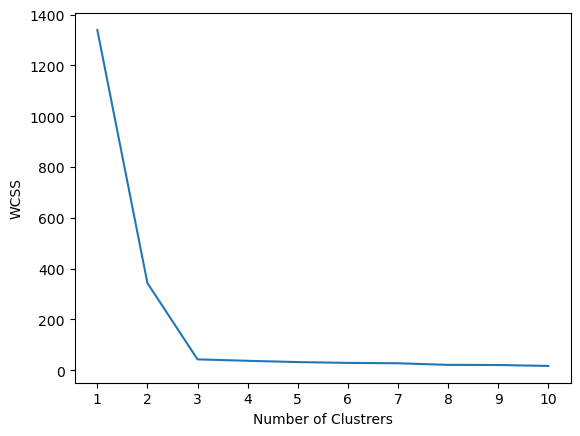

In [19]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [20]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [21]:
kmeans.fit_predict(X_train_scaled)

array([0, 1, 2, 0, 2, 0, 2, 1, 0, 2, 1, 0, 2, 2, 1, 2, 0, 2, 2, 2, 0, 2,
       1, 1, 0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 0, 0, 1, 0, 0, 2, 0, 2, 1,
       0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 2, 2, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 2, 1, 2, 0, 1, 2, 0, 2, 1, 1, 2, 2, 0, 1, 0, 0, 2, 2, 0, 0,
       2, 1, 1, 2, 1, 0, 0, 0, 0, 2, 2, 2, 1, 0, 1, 2, 2, 2, 1, 0, 2, 0,
       2, 0, 2, 1, 2, 0, 1, 1, 0, 1, 1, 2, 0, 0, 1, 0, 0, 0, 1, 2, 1, 1,
       2, 1, 1, 1, 1, 2, 0, 2, 0, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 2, 1, 0, 0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 2, 0, 2,
       0, 1, 0, 2, 2, 0, 0, 1, 2, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 2, 0, 2, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 2, 0, 2, 0, 1, 2, 1, 1,
       2, 2, 2, 0, 0, 2, 2, 2, 0, 1, 0, 2, 1, 0, 1, 0, 2, 2, 0, 1, 0, 2,
       2, 2, 0, 0, 1, 0, 2, 0, 0, 1, 1, 2, 0, 2, 0, 0, 2, 1, 2, 2, 1, 1,
       0, 2, 1, 2, 1, 1, 0, 1, 2, 1, 1, 1, 0, 1, 0, 2, 0, 2, 0, 1, 0, 0,
       2, 0, 1, 0, 2, 1, 0, 0, 2, 2, 0, 2, 0, 1, 2,

In [22]:
y_pred=kmeans.predict(X_test_scaled)

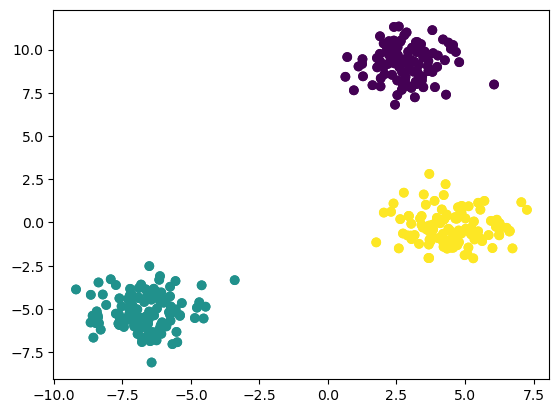

In [24]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()

In [ ]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [25]:
##kneelocator
!pip install kneed

In [26]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [27]:
kl.elbow

np.int64(3)

In [29]:
#silhoute score
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

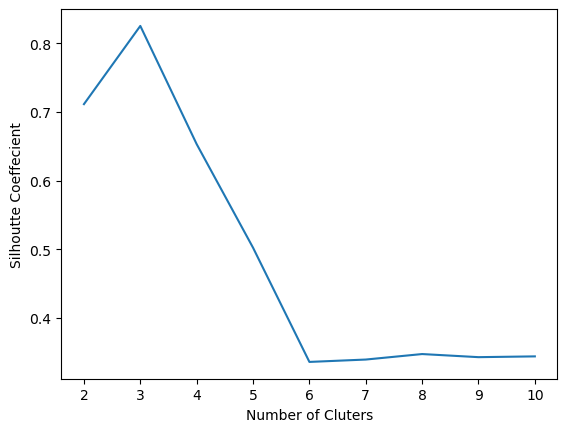

In [30]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()